In [1]:
import gc
import random
import shutil
import os

import psycopg
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

tqdm.pandas()

import dataset
import utils
import model as model_imp


SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.cuda.set_device(0)


# podman run --rm -d --name beauty_db -e POSTGRES_DB=beauty_data -e POSTGRES_USER=postgres -e POSTGRES_PASSWORD=pass -e PGDATA=/var/lib/postgresql/data/pgdata -v postgres_data:/var/lib/postgresql/data -p5432:5432  postgres
# --- 1. Database Connection Details (Replace with your actual details) ---
DB_NAME = "beauty_data"
DB_USER = "postgres"
DB_PASS = "pass"
DB_HOST = "localhost"  # or your host address
DB_PORT = "5432"


def get_conn():
    conn = psycopg.connect(
        dbname=DB_NAME, user=DB_USER, password=DB_PASS, host=DB_HOST, port=DB_PORT
    )
    return conn


def setup_database(conn):
    """Creates the photo_embeddings table if it doesn't exist."""
    CREATE_TABLE_SQL = """
CREATE TABLE IF NOT EXISTS photo_embeddings (
    folder_name VARCHAR(15) NOT NULL,
    photo_id VARCHAR(255) NOT NULL,
    embedding REAL[],
    -- Define the composite unique constraint
    CONSTRAINT uq_person_photo UNIQUE (folder_name, photo_id)
);
"""
    with conn.cursor() as cursor:
        cursor.execute(CREATE_TABLE_SQL)
        cursor.execute(
            """CREATE INDEX IF NOT EXISTS idx_folder_name ON photo_embeddings (folder_name);"""
        )


CONF = utils.load_conf("conf.yaml")[0]
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
BASEPATH = CONF["DATASET_PHOTO_BASEPATH"]
CONF

2025-10-21 22:50:27.347004: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


{'C': 3,
 'H': 224,
 'W': 224,
 'F_H': 224,
 'F_W': 224,
 'N_MAX': 9,
 'N_CLASSES': 9,
 'DATASET_FILE': 'datasets/beauty_dataset.csv',
 'DATASET_PHOTO_BASEPATH': '/media/ground0/31E7643363A5E093/opt/SP/dataset/beauty_dataset',
 'BATCH_SIZE': 32,
 'LR': 0.0001,
 'EPOCHS': 10,
 'MODEL': 'models/model_v8_classes_big_finetuned_state_dict.pt',
 'PATIENCE': 2}

In [2]:
def load_dataset(dataset):
    df = pd.read_csv(dataset, usecols=["folder_name", "score"])
    df = (
        df[~df["score"].isna()]
        .drop_duplicates()
        .reset_index(drop=True)
        .convert_dtypes()
    )
    return df


df = load_dataset(CONF["DATASET_FILE"])
mask = df["folder_name"].progress_apply(
    lambda x: os.path.exists(os.path.join(BASEPATH, x))
)
df = df[mask]

  0%|          | 0/7000 [00:00<?, ?it/s]

In [3]:
def cache_dataset(df, basepath, cache_path):
    try:
        os.makedirs(cache_path, exist_ok=False)
    except:
        pass

    for folder_name in tqdm(list(df["folder_name"].unique())):
        dst = os.path.join(cache_path, folder_name)
        src = os.path.join(basepath, folder_name)
        if not os.path.exists(dst) and os.path.exists(src):
            shutil.copytree(src, dst, symlinks=True)


cache_dataset(df, BASEPATH, "/dev/shm/image_dataset")
BASEPATH = "/dev/shm/image_dataset"

  0%|          | 0/6997 [00:00<?, ?it/s]

<Axes: ylabel='score'>

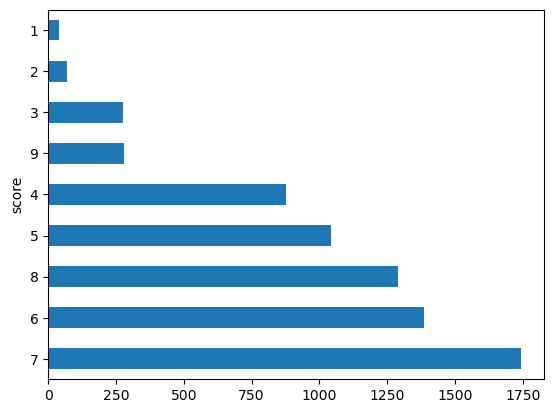

In [4]:
t = df["score"].value_counts()
t.plot(kind="barh")

In [5]:
utils.compute_class_weights(df), df["score"].value_counts().sort_index()

(tensor([5.0000, 5.0000, 2.8168, 0.8875, 0.7454, 0.5617, 0.4466, 0.6031, 2.7766]),
 score
 1      39
 2      69
 3     276
 4     876
 5    1043
 6    1384
 7    1741
 8    1289
 9     280
 Name: count, dtype: Int64)

In [6]:
raw_dataset = utils.load_raw_dataset(df, BASEPATH)
unique_scores = set([row["score"] for row in raw_dataset])
MAX_SCORE = max(unique_scores)
MIN_SCORE = min(unique_scores)
assert MAX_SCORE - MIN_SCORE == CONF["N_CLASSES"] - 1
raw_dataset[0]

{'id': 'person_1',
 'score': 7,
 'photos': ['/dev/shm/image_dataset/person_1/photo_8.jpg',
  '/dev/shm/image_dataset/person_1/photo_7.jpg',
  '/dev/shm/image_dataset/person_1/photo_6.jpg',
  '/dev/shm/image_dataset/person_1/photo_5.jpg',
  '/dev/shm/image_dataset/person_1/photo_4.jpg',
  '/dev/shm/image_dataset/person_1/photo_3.jpg',
  '/dev/shm/image_dataset/person_1/photo_2.jpg',
  '/dev/shm/image_dataset/person_1/photo_1.jpg',
  '/dev/shm/image_dataset/person_1/photo_0.jpg']}

In [7]:
row = next(iter(raw_dataset))
row

{'id': 'person_1',
 'score': 7,
 'photos': ['/dev/shm/image_dataset/person_1/photo_8.jpg',
  '/dev/shm/image_dataset/person_1/photo_7.jpg',
  '/dev/shm/image_dataset/person_1/photo_6.jpg',
  '/dev/shm/image_dataset/person_1/photo_5.jpg',
  '/dev/shm/image_dataset/person_1/photo_4.jpg',
  '/dev/shm/image_dataset/person_1/photo_3.jpg',
  '/dev/shm/image_dataset/person_1/photo_2.jpg',
  '/dev/shm/image_dataset/person_1/photo_1.jpg',
  '/dev/shm/image_dataset/person_1/photo_0.jpg']}

In [8]:
emb = utils.get_face_embedding(raw_dataset[0]["photos"][0])
emb

tensor([-0.1111,  0.1065,  0.0777,  0.0138, -0.1093, -0.0942,  0.0069, -0.0845,  0.1160, -0.0783,  0.1764,  0.0009, -0.2654, -0.0190,  0.0336,  0.1436, -0.1296, -0.1325, -0.1633,  0.0149,  0.0455,  0.0509,  0.0578,  0.0456, -0.1269, -0.3020, -0.0929, -0.0680, -0.0143, -0.0670, -0.0197,  0.1342, -0.0951,  0.0045,
         0.0327,  0.0111, -0.0323, -0.0722,  0.2310, -0.0075, -0.2931, -0.0798,  0.0648,  0.2522,  0.2424, -0.0492,  0.0703, -0.0618,  0.0354, -0.2836,  0.0025,  0.1737,  0.0814,  0.0681,  0.0916, -0.1530, -0.0381,  0.1362, -0.1452,  0.0308,  0.0928, -0.1261, -0.0704, -0.1427,  0.2257,  0.1271, -0.1874, -0.1447,
         0.1276, -0.1904, -0.1006,  0.1041, -0.1421, -0.1987, -0.2532, -0.0222,  0.3694,  0.1464, -0.1807,  0.0234, -0.1122, -0.0442,  0.0089,  0.1271, -0.0540, -0.0058, -0.0752,  0.0202,  0.2185, -0.0499,  0.0111,  0.2174,  0.0099, -0.0326, -0.0221,  0.0096, -0.0467, -0.0175, -0.1030,  0.0278, -0.0110, -0.1247,
        -0.0068,  0.0909, -0.1262,  0.1394, -0.0027,  0.02

In [9]:
def get_already_processed_photos():
    with psycopg.connect(
        dbname=DB_NAME, user=DB_USER, password=DB_PASS, host=DB_HOST, port=DB_PORT
    ) as conn:

        with conn.cursor() as cursor:
            cursor.execute("""select folder_name, photo_id from photo_embeddings""")
            df = pd.DataFrame(cursor.fetchall())
            df.columns = ["id", "photos"]
            return df


processed_records = get_already_processed_photos()
raw_df = pd.DataFrame(raw_dataset).explode("photos")[["id", "photos"]]
raw_df["photos"] = raw_df["photos"].apply(lambda x: os.path.basename(x))
merged_df = pd.merge(
    processed_records, raw_df, on=["id", "photos"], how="outer", indicator=True
)
mask = merged_df["_merge"] != "both"
df_missing_photos = merged_df[mask]
df_missing_photos.head(3)

,id,photos,_merge


In [10]:
missing_dataset = []
for l, g in df_missing_photos.groupby("id"):
    missing_dataset.append(
        {
            "id": l,
            "photos": g["photos"]
            .apply(lambda x: os.path.join(BASEPATH, l, x))
            .to_list(),
        }
    )
missing_dataset

[]

In [11]:
def process_and_save_photos(dataset):
    # Establish database connection
    conn = None
    try:
        with get_conn() as conn:
            setup_database(conn)
            with conn.cursor() as cursor:

                # Define the SQL insert statement
                # The %s placeholders will be replaced by the values in the execute call.
                # We cast the third value to REAL[] to ensure the array format is correct.
                INSERT_SQL = """
                INSERT INTO photo_embeddings (folder_name, photo_id, embedding)
                VALUES (%s, %s, %s::REAL[]);
                """

                for row in tqdm(dataset):
                    for photo in row["photos"]:
                        try:
                            embedding = utils.get_face_embedding(photo)

                            if embedding is None:
                                embedding = []
                            else:
                                embedding = embedding.tolist()
                                
                            data = (row["id"], os.path.basename(photo), embedding)
                            cursor.execute(INSERT_SQL, data)

                        except Exception as e:
                            print(f"❌ Error processing {os.path.basename(photo)}: {e}")
                            cursor.execute("ROLLBACK")
                            conn.commit()
                    conn.commit()
                conn.commit()
                print("\n✨ All operations complete. Data committed to database.")

    except psycopg.Error as db_err:
        print(f"Database connection error: {db_err}")


process_and_save_photos(missing_dataset)

0it [00:00, ?it/s]


✨ All operations complete. Data committed to database.


In [12]:
conn = get_conn()
cursor = conn.cursor()
ids = ['person_1','person_2','person_4']
cursor.execute("""select folder_name,photo_id, embedding from photo_embeddings where folder_name = ANY(%s) order by folder_name asc, photo_id desc """,[ids])
x = pd.DataFrame(cursor.fetchall())
x.columns = ['folder_name', 'photo_id', 'embedding']

In [13]:
res = []
for l,g in x.groupby('folder_name'):
    res.append({'id':l,'embeddings':g['embedding'].to_list()})
len(res)

3

In [14]:
face_embedding = res[0]['embeddings']
len(face_embedding)

9

In [15]:
torch.Tensor(face_embedding)

tensor([[-0.1111,  0.1065,  0.0777,  ..., -0.0441,  0.0353, -0.0012],
        [-0.1111,  0.1065,  0.0777,  ..., -0.0441,  0.0353, -0.0012],
        [-0.0698,  0.0393,  0.0843,  ..., -0.0455, -0.0373, -0.0092],
        ...,
        [-0.0605,  0.0473, -0.0004,  ..., -0.0629,  0.0140,  0.0469],
        [-0.0371,  0.0733,  0.0710,  ..., -0.0455, -0.0554,  0.0249],
        [-0.0757,  0.0226,  0.0068,  ..., -0.0244,  0.0003,  0.0474]])

In [16]:
import importlib
importlib.reload(dataset)

<module 'dataset' from '/media/ground0/31E7643363A5E093/opt/SP/WORKSPACE/python/BeautyScorer/dataset.py'>

In [17]:
conn = get_conn()
raw_ds = dataset.BeautyDataset(raw_dataset,conn.cursor())
for i,x in enumerate(raw_ds):
    print(x)
    if i == 2 :
        break

{'id': 'person_1', 'score': 7, 'photos': ['/dev/shm/image_dataset/person_1/photo_8.jpg', '/dev/shm/image_dataset/person_1/photo_7.jpg', '/dev/shm/image_dataset/person_1/photo_6.jpg', '/dev/shm/image_dataset/person_1/photo_5.jpg', '/dev/shm/image_dataset/person_1/photo_4.jpg', '/dev/shm/image_dataset/person_1/photo_3.jpg', '/dev/shm/image_dataset/person_1/photo_2.jpg', '/dev/shm/image_dataset/person_1/photo_1.jpg', '/dev/shm/image_dataset/person_1/photo_0.jpg']}
{'id': 'person_2', 'score': 9, 'photos': ['/dev/shm/image_dataset/person_2/photo_3.jpg', '/dev/shm/image_dataset/person_2/photo_2.jpg', '/dev/shm/image_dataset/person_2/photo_1.jpg', '/dev/shm/image_dataset/person_2/photo_0.jpg']}
{'id': 'person_4', 'score': 4, 'photos': ['/dev/shm/image_dataset/person_4/photo_1.jpg', '/dev/shm/image_dataset/person_4/photo_0.jpg']}


In [18]:
BATCH_SIZE = CONF["BATCH_SIZE"]
raw_dl = DataLoader(
    raw_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    collate_fn=raw_ds.collate_fn,
)
for x in raw_dl:
    # print(x)
    for a, b in zip(x.keys(), x.values()):
        print(f"{a} -> {b.shape}")
    break

ids -> (32,)
photos_tensor -> torch.Size([32, 9, 3, 224, 224])
photos_mask -> torch.Size([32, 9])
faces_tensor -> torch.Size([32, 9, 128])
faces_mask -> torch.Size([32, 9])
scores -> torch.Size([32])


In [19]:
lr = CONF["LR"]
EPOCHS = CONF["EPOCHS"]

model = model_imp.BeautyScoreModel(conf=CONF)
model_params = list(filter(lambda p: p.requires_grad, model.parameters()))

class_weights = utils.compute_class_weights(df)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)
optimizer = optim.AdamW(model_params, lr=lr, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

finetune = CONF["MODEL"]
if finetune != "":
    try:
        model.load_state_dict(torch.load(finetune, weights_only=True))
    except Exception as e:
        print(f"Impossible to load model due to {e}. Training from scratch")

Impossible to load model due to Error(s) in loading state_dict for BeautyScoreModel:
	size mismatch for face_proj.weight: copying a param with shape torch.Size([512, 960]) from checkpoint, the shape in current model is torch.Size([512, 128]).. Training from scratch


In [20]:
# Assert that changing the order of the images does not change the result
def randomize(t1, t2):
    idx = torch.randperm(t1.shape[1])
    t1 = t1[:, idx].view(t1.size())
    t2 = t2[:, idx].view(t2.size())
    return t1, t2


a, b = randomize(x["photos_tensor"], x["photos_mask"])
c, d = randomize(x["faces_tensor"], x["faces_mask"])
model.eval()
res1 = model(x["photos_tensor"], x["photos_mask"], x["faces_tensor"], x["faces_mask"])
res2 = model(a, b, c, d)
model.train()
(res1 - res2).abs().max()

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


tensor(8.3447e-07, grad_fn=<MaxBackward1>)

In [ ]:
N_CLASSES = CONF["N_CLASSES"]
STEPS = len(raw_ds) // BATCH_SIZE
CLASS_DELTA = MAX_SCORE - N_CLASSES
PATIENCE = CONF["PATIENCE"]


def train(model, dl_train):
    best_loss = 100
    early_stop_counter = 0
    for epoch in tqdm(range(EPOCHS), position=0):
        model.train()
        train_loss = 0
        with tqdm(dl_train, total=STEPS, position=1) as pbar:
            for step, batch in enumerate(pbar):
                photos_tensor = batch["photos_tensor"].to(device)
                photos_mask = batch["photos_mask"].to(device)
                faces_tensor = batch["faces_tensor"].to(device)
                faces_mask = batch["faces_mask"].to(device)
                labels = batch["scores"].to(device) - MIN_SCORE  # 0-8

                optimizer.zero_grad()
                # with torch.amp.autocast(
                #     device_type=torch.device
                # ):
                logits = model(photos_tensor, photos_mask, faces_tensor, faces_mask)
                loss = criterion(logits, labels.long())

                # scaler.scale(loss).backward()
                # scaler.step(optimizer)
                # scaler.update()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                pbar.set_description(
                    f"Epoch {epoch+1}/{EPOCHS} - Train - Loss: {round(train_loss / (step+1),4)}"
                )

            avg_train_loss = train_loss / STEPS
            model_imp.score_persons(batch, model, 5, BASEPATH)
            scheduler.step()  # Update LR

            # Early stopping
            if avg_train_loss < best_loss:
                best_loss = avg_train_loss
                torch.save(model.state_dict(), "models/model_state_dict.pth")
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= PATIENCE:
                    print(f"Early stopping at epoch {epoch+1}")
                    break
    return model


gc.collect()
torch.cuda.empty_cache()
model.to(device)
model = train(model, raw_dl)
torch.save(model.state_dict(), "models/model_state_dict_final.pt")
torch.save(model, "models/model.pt")

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/218 [00:00<?, ?it/s]

# INFERENCE

In [ ]:
import datasets

faces_example = datasets.load_dataset("logasja/lfw", split="train", streaming=True)

In [ ]:
examples = []
for idx, row in tqdm(enumerate(faces_example)):
    examples.append(row)
    if idx > 1000:
        break

In [ ]:
import pandas as pd

example_df = pd.DataFrame(examples)

In [ ]:
import os

tmp_folder = "/dev/shm/example_dataset"
os.makedirs(tmp_folder, exist_ok=True)

In [ ]:
for label, group in tqdm(
    example_df.groupby("label"), total=example_df["label"].nunique()
):
    if len(group) < 2:
        continue
    os.makedirs(f"{tmp_folder}/{label}", exist_ok=True)
    for idx, row in group.iterrows():
        row["image"].save(f"{tmp_folder}/{label}/{idx}.jpg")

In [ ]:
from glob import glob

raw_dataset = []
for label in example_df["label"].astype(str).unique():
    raw_dataset.append(
        {"id": label, "score": -1, "photos": glob(f"{tmp_folder}/{label}/*")}
    )
raw_dataset = list(filter(lambda x: len(x["photos"]) > 0, raw_dataset))
raw_dataset[0]

In [ ]:
example_person = random.choice(raw_dataset)
example_person

In [ ]:
utils.show_person(example_person["id"], tmp_folder)

In [ ]:
score, probs = score_person(example_person["id"], model, tmp_folder)
print(f"Score: {score} | Probabilities: {probs}")